In [3]:
# Cell 1 — load + parse
import json, re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

RUNS_DIR = Path("/workspace/runs")
RECORDS = Path("/workspace/parameter-golf/records/track_10min_16mb")

CONFIGS = [
    ("lb_baseline",      "1. Baseline",        "2026-03-17_NaiveBaseline",                                          "tab:gray"),
    ("lb_slide64",       "2. SlidingWindow",   "2026-03-19_SlidingWindowEval",                                      "tab:blue"),
    ("lb_lora_ttt",      "3. LoRA TTT",        "2026-03-17_LoRA_TTT",                                               "tab:green"),
    ("lb_11l_ema_gptq",  "4. 11L EMA+GPTQ",    "2026-03-22_11L_EMA_GPTQ-lite_warmdown3500_QAT015_1.1233",           "tab:orange"),
    ("lb_par_resid_dr",  "5. ParResid+MiniDR", "2026-03-31_ParallelResiduals_MiniDepthRecurrence",                  "tab:red"),
]

# Match the LAST score-bearing line in each config's .txt log
SCORE_PATTERNS = [
    re.compile(r"final_int8_zlib_roundtrip_exact\s+val_loss:([\d.]+)\s+val_bpb:([\d.]+)"),
    re.compile(r"final_int8_zlib_roundtrip\s+val_loss:([\d.]+)\s+val_bpb:([\d.]+)"),
    re.compile(r"final_int8_ttt_lora\s+val_loss:([\d.]+)\s+val_bpb:([\d.]+)"),
    re.compile(r"final_int6_sliding_window_exact\s+val_loss:([\d.]+)\s+val_bpb:([\d.]+)"),
    re.compile(r"quantized_ttt_phased\s+val_loss:([\d.]+)\s+val_bpb:([\d.]+)"),
]

def parse_val_bpb(txt_path):
    """Last score line wins — that's the canonical leaderboard score."""
    if not txt_path.exists(): return None
    last = None
    for line in txt_path.read_text().splitlines():
        for pat in SCORE_PATTERNS:
            m = pat.search(line)
            if m:
                last = float(m.group(2))
    return last

runs = {}
for run_id, label, sub_dir, color in CONFIGS:
    jsonl = RUNS_DIR / f"{run_id}.jsonl"
    log_dir = RECORDS / sub_dir / "logs"
    txt = log_dir / f"{run_id}.txt"
    # Fallback to any .txt in logs/ if RUN_ID-named one isn't there
    if not txt.exists():
        txts = list(log_dir.glob("lb_*.txt")) or list(log_dir.glob("*.txt"))
        txt = txts[0] if txts else txt
    
    records = [json.loads(l) for l in jsonl.read_text().splitlines() if l.strip()]
    se = next(r for r in records if r.get("type") == "session_end")
    steps = [r for r in records if r.get("type") == "step"]
    bpb = parse_val_bpb(txt)
    
    runs[run_id] = {"label": label, "bpb": bpb, "color": color, "se": se, "steps": steps, "txt": txt}
    print(f"{label}: val_bpb={bpb}, kWh={se['energy_wh']/1000:.3f}, dur={se['duration_s']:.0f}s")

1. Baseline: val_bpb=1.22551439, kWh=1.090, dur=807s
2. SlidingWindow: val_bpb=1.19259415, kWh=1.035, dur=773s
3. LoRA TTT: val_bpb=1.1923, kWh=0.996, dur=734s
4. 11L EMA+GPTQ: val_bpb=1.12328796, kWh=1.105, dur=888s
5. ParResid+MiniDR: val_bpb=1.10553767, kWh=1.346, dur=1300s


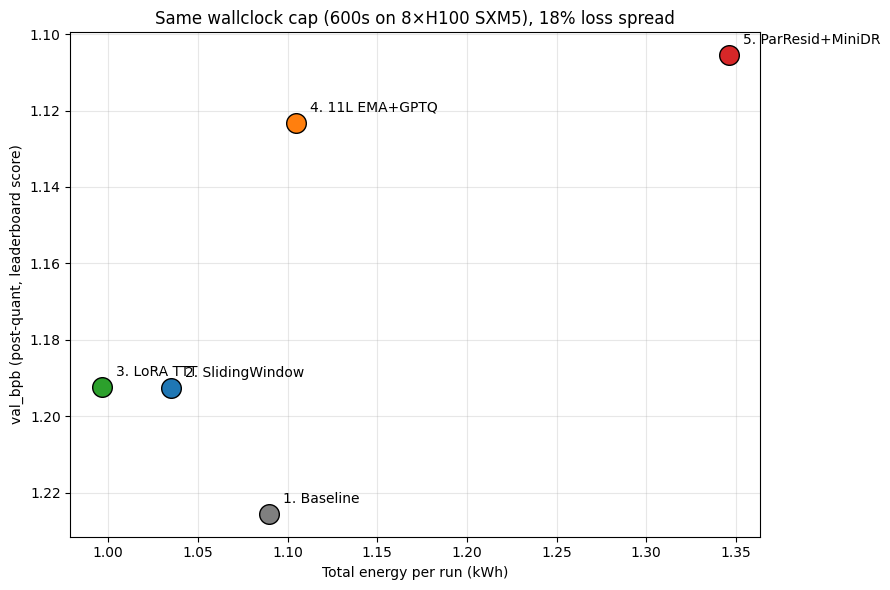

In [4]:
# Cell 2 — Hero chart: val_bpb vs total kWh
fig, ax = plt.subplots(figsize=(9, 6))
for run_id, r in runs.items():
    kwh = r["se"]["energy_wh"] / 1000
    ax.scatter(kwh, r["bpb"], s=200, color=r["color"], zorder=3, edgecolors='black', linewidths=1)
    ax.annotate(r["label"], (kwh, r["bpb"]),
                xytext=(10, 8), textcoords='offset points', fontsize=10)
ax.set_xlabel("Total energy per run (kWh)")
ax.set_ylabel("val_bpb (post-quant, leaderboard score)")
ax.set_title("Same wallclock cap (600s on 8×H100 SXM5), 18% loss spread")
ax.grid(True, alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("/workspace/runs/01_hero_loss_vs_energy.png", dpi=150)
plt.show()

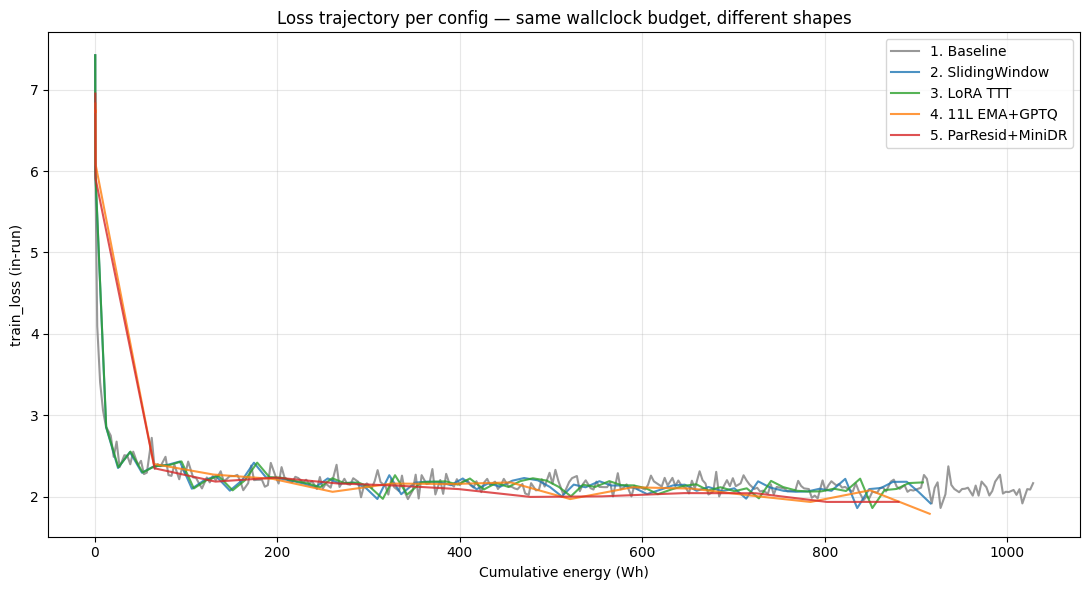

In [5]:
# Cell 3 — Loss vs cumulative energy curves
fig, ax = plt.subplots(figsize=(11, 6))
for run_id, r in runs.items():
    cum_wh, ys = 0.0, []
    for rec in r["steps"]:
        cum_wh += rec["energy_j"] / 3600
        m = rec.get("train_metrics", {})
        loss = m.get("train_loss")
        if loss is not None and rec["step"] > 5:
            ys.append((cum_wh, loss))
    if ys:
        xs, ls = zip(*ys)
        ax.plot(xs, ls, label=r["label"], color=r["color"], linewidth=1.5, alpha=0.8)
ax.set_xlabel("Cumulative energy (Wh)")
ax.set_ylabel("train_loss (in-run)")
ax.set_title("Loss trajectory per config — same wallclock budget, different shapes")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/workspace/runs/02_loss_vs_cumulative_energy.png", dpi=150)
plt.show()

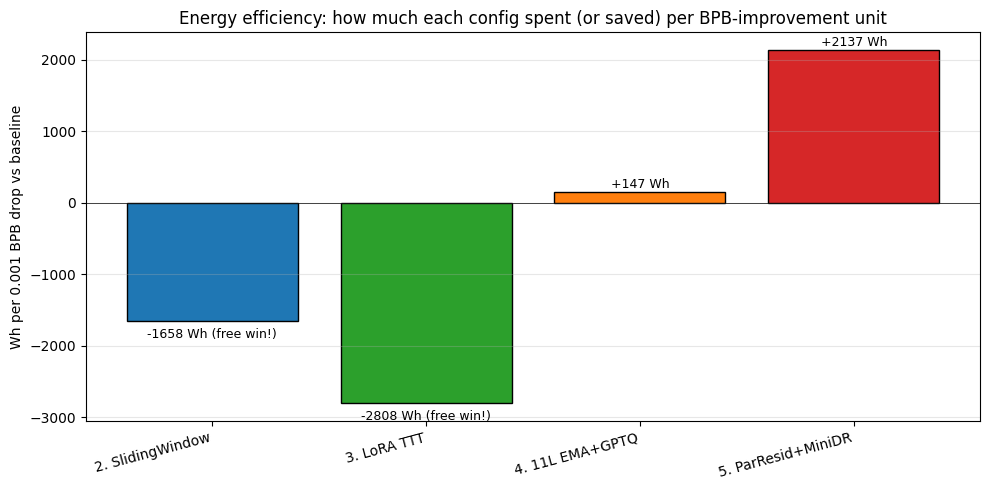

In [6]:
# Cell 4 — Energy efficiency bar (Wh per 0.001 BPB-drop vs baseline)
base = runs["lb_baseline"]
labels, ratios, colors = [], [], []
for run_id, r in runs.items():
    if run_id == "lb_baseline": continue
    db = r["bpb"] - base["bpb"]
    dw = r["se"]["energy_wh"] - base["se"]["energy_wh"]
    if abs(db) > 1e-6:
        labels.append(r["label"])
        ratios.append(-dw / db)
        colors.append(r["color"])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, ratios, color=colors, edgecolor='black')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel("Wh per 0.001 BPB drop vs baseline")
ax.set_title("Energy efficiency: how much each config spent (or saved) per BPB-improvement unit")
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, ratios):
    label = f"{val:+.0f} Wh" + (" (free win!)" if val < 0 else "")
    ax.annotate(label, (bar.get_x() + bar.get_width()/2, val),
                xytext=(0, 3 if val > 0 else -12), textcoords='offset points',
                ha='center', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("/workspace/runs/03_energy_efficiency.png", dpi=150)
plt.show()

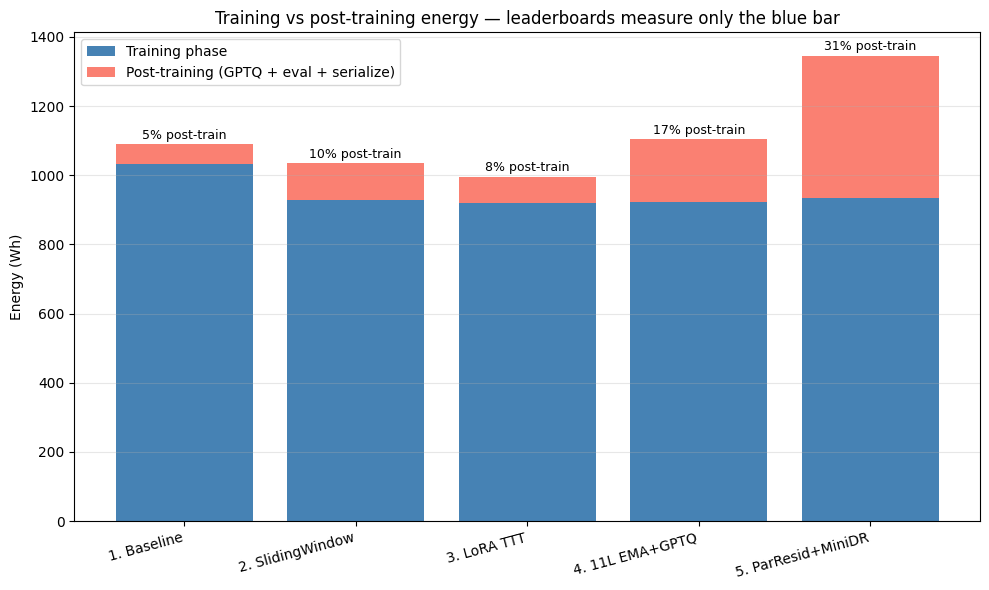

In [7]:
# Cell 5 — Training vs Post-training stacked bar
labels, train_wh, post_wh = [], [], []
for run_id, r in runs.items():
    se = r["se"]
    train_step_energy = sum(rec["energy_j"] for rec in r["steps"]) / 3600
    post = se["energy_wh"] - train_step_energy
    labels.append(r["label"])
    train_wh.append(train_step_energy)
    post_wh.append(post)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(labels))
ax.bar(x, train_wh, label="Training phase", color='steelblue')
ax.bar(x, post_wh, bottom=train_wh, label="Post-training (GPTQ + eval + serialize)", color='salmon')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel("Energy (Wh)")
ax.set_title("Training vs post-training energy — leaderboards measure only the blue bar")
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
for i, (t, p) in enumerate(zip(train_wh, post_wh)):
    pct = p / (t+p) * 100
    ax.annotate(f"{pct:.0f}% post-train",
                (i, t+p), xytext=(0, 4), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("/workspace/runs/04_train_vs_post_train_energy.png", dpi=150)
plt.show()

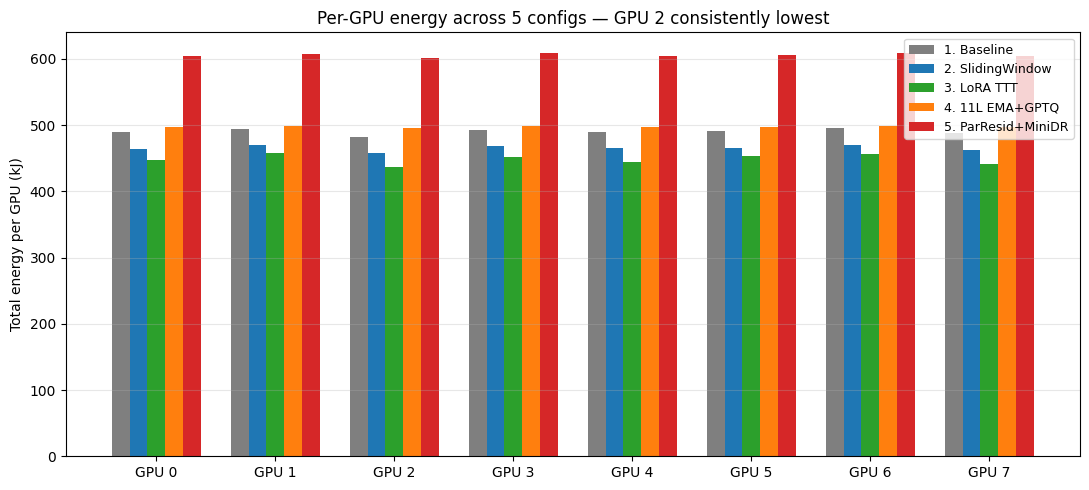

In [8]:
# Cell 6 — Per-GPU energy bars (the GPU 2 straggle story)
fig, ax = plt.subplots(figsize=(11, 5))
width = 0.15
x = np.arange(8)
for i, (run_id, r) in enumerate(runs.items()):
    energies_kj = [g["energy_j"]/1000 for g in sorted(r["se"]["gpus"], key=lambda g: g["idx"])]
    ax.bar(x + i*width, energies_kj, width, label=r["label"], color=r["color"])
ax.set_xticks(x + width*2); ax.set_xticklabels([f"GPU {i}" for i in range(8)])
ax.set_ylabel("Total energy per GPU (kJ)")
ax.set_title("Per-GPU energy across 5 configs — GPU 2 consistently lowest")
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/workspace/runs/05_per_gpu_straggle.png", dpi=150)
plt.show()